#**Maestría en Inteligencia Artificial Aplicada**
##**Curso: Procesamiento de Lenguaje Natural (NLP)**
###Tecnológico de Monterrey
###Prof Luis Eduardo Falcón Morales

## **Adtividad de la Semana: Análisis de Sentimiento**

###**Pre-procesamiento, Matrices Documeto-Término (DTM) y TF-IDF.**

* **Nombre:** Javier Emmanuel García Escobedo

* **matrícula:** A01411206

En esta actividad deberás utilizar los datos de tres archivos que se encuentran en el repositorio de la UCI que te indico más abajo:

*   **amazon_cells_labelled.txt** Contiene 1000 registros de comentarios de usuarios que adquirieron un producto a través de la plataforma de Amazon.

*   **imdb_labelled.txt** Contiene 1000 registros de comentarios que dejaron usuarios sobre palículas y series en la plataforma de IMBD.

*   **yelp_labelled.txt** Contiene 1000 comentarios de usuarios sobre servicios de comida dejados en l aplataforma de Yelp.

La información del problema y de los archivos están basados en el repositorio de la UCI. Descarga los archivos de la suguiente liga:

https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

import re
import string

from sklearn.metrics import confusion_matrix

In [12]:
nltk.download('punkt')    # es un tokenizador que ayuda a dividr el texto en enunciados mediante un modelo no-supervisado.
nltk.download('stopwords')    # para tener acceso a "stopwords" en varios idiomas.

[nltk_data] Downloading package punkt to C:\Users\Go
[nltk_data]     Credit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Go
[nltk_data]     Credit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

##**Pregunta - 1:**



* ### Comenta qué significa en este problema un Falso-Negativo y un Falso-Positivo. ¿Qué implicaciones podrían tener cada uno de estos errores?

* ### ¿Cuál tipo de error se podría considerar más grave en el contexto del problema? ¿O serían igual de importantes cada uno? Justifica tu respuesta.

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 1:**


En este problema la clase positiva (label = 1) corresponde a un comentario que expresa una opinión **favorable** sobre el producto, película o restaurante, y la clase negativa (label = 0) corresponde a un comentario **desfavorable**.

**Falso Positivo (FP):** el modelo predice que un comentario es positivo cuando en realidad es negativo. En la práctica, esto significa que una queja o crítica del usuario sería clasificada como una opinión favorable y, por lo tanto, pasaría desapercibida. Implicaciones: la empresa no detectaría problemas reales (productos defectuosos, mal servicio, películas que decepcionan), no podría tomar acciones correctivas y se perderían oportunidades de mejora. Además, en sistemas de recomendación, podríamos recomendar productos/películas que realmente generan insatisfacción.

**Falso Negativo (FN):** el modelo predice que un comentario es negativo cuando en realidad es positivo. En la práctica, una recomendación entusiasta sería marcada como crítica. Implicaciones: se subestima la aceptación real del producto o servicio, se podrían tomar decisiones equivocadas de retirar productos que sí gustan, y se desperdicia evidencia favorable que podría usarse en marketing.

**¿Cuál es más grave?** En el contexto de análisis de sentimiento sobre reseñas de usuarios, considero que **el Falso Positivo es más grave**, porque clasificar una queja como elogio impide detectar problemas reales del negocio (calidad, servicio al cliente, defectos). Una queja no atendida puede escalar (redes sociales, devoluciones, pérdida de clientes), mientras que dejar de capitalizar un elogio tiene un costo de oportunidad menor y reversible. Dicho esto, en un dataset perfectamente balanceado como el nuestro y sin un costo de negocio explícito, ambos errores son tratados con el mismo peso por la accuracy. Si quisiéramos penalizar más los FP, deberíamos optimizar **precisión** sobre la clase positiva (o usar F-beta con beta < 1) en lugar de accuracy.


##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################

Stopwords:

Como en un problema de análisis de sentimiento solo se desea determinar si un comentario es una reseña positivas o una reseña negativa, pudiera ser importante considerar los conectivos "negativos". Como dichos conectivos están incluidos de manera predeterminada en la lista de "stopwords" de la librería NLTK, los vamos a excluir de dicha lista, para que sí sean parte del vocabulario que estaremos analizando.

A la nueva lista de stopwords la llamaremos **mystopwords**.

In [13]:
# Veamos la lista de stopwords que se incluyen de manera predeterminada la suite de librerías de NLTK:

print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [14]:
# Consideremos la siguiente lista de palabras asociada a negaciones en inglés:

negwords = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

# Y las excluimos de las stopwords:
mystopwords = [ w for w in stopwords.words('english') if w not in negwords]


print("Total de stopwords en la lista original de NLTK: %d" % len(stopwords.words('english')))
print("Total de sotpwords excluyendo los conectivos negativos: %d\n" % len(mystopwords))

# Nuestra nueva lista:
print(mystopwords)

Total de stopwords en la lista original de NLTK: 198
Total de sotpwords excluyendo los conectivos negativos: 158

['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am', 'an', 'and', 'any', 'are', 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'd', 'did', 'do', 'does', 'doing', 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'has', 'have', 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'more', 'most', 'my', 'myself', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'she', "she'd", "she'll", "she's", 'should', "should've", 'so', 'some', 'such', 't', 'than', 'that', "that'll", 'the', 'their', 'theirs', 'them', 'themselves', 'th

###**Cargamos los datos del problema:**

In [15]:
# Puedes modificar en dado caso la ruta de los archivos:

dfa = pd.read_csv('amazon_cells_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')
dfi = pd.read_csv('imdb_labelled.txt', delimiter='\t', names=['review','label'], header=None, encoding='utf-8')
dfy = pd.read_csv('yelp_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')


print('Total de registros de Amazon:',dfa.shape)
print('Total de registros de IMBD:',dfi.shape)
print('Total de registros de Yelp:',dfy.shape)

Total de registros de Amazon: (1000, 2)
Total de registros de IMBD: (748, 2)
Total de registros de Yelp: (1000, 2)


La salida anterior esperada es la siguiente:

Total de registros de Amazon: (1000, 2)

Total de registros de IMBD: (748, 2)

Total de registros de Yelp: (1000, 2)

In [16]:
dfa.head()     # Cada uno de estos data frame está formado de dos columnas,
               # uno con los comentarios (review) y otro con la etiqueta (label).
               # Por ejemplo, mostremos a continuación los primeros comentarios
               # y etiquetas del archivo de Amazon:

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


Sin embargo, observa que los registros de IMBD no son los 1000 que se indican en la documentación de estos datos, sino 748.

En realidad no son datos perdidos, sino que varios de ellos fueron capturados errónamente como uno solo. En ocasiones, la gran cantidad de caracteres especiales que existen actualmente pueden generar errores de este tipo.

Por ejemplo, observa la salida siguiente y cómo el registro de índice 19 tiene una gran cantidad de registros conjuntados como uno solo.



In [17]:
dfi.values.tolist()[17:21]

[["I'll put this gem up against any movie in terms of screenplay, cinematography, acting, post-production, editing, directing, or any other aspect of film-making.  ",
  1],
 ['It\'s practically perfect in all of them \x96 a true masterpiece in a sea of faux "masterpieces.  ',
  1],
 [' The structure of this film is easily the most tightly constructed in the history of cinema.  \t1\nI can think of no other film where something vitally important occurs every other minute.  \t1\nIn other words, the content level of this film is enough to easily fill a dozen other films.  \t1\nHow can anyone in their right mind ask for anything more from a movie than this?  \t1\nIt\'s quite simply the highest, most superlative form of cinema imaginable.  \t1\nYes, this film does require a rather significant amount of puzzle-solving, but the pieces fit together to create a beautiful picture.  \t1\nThis short film certainly pulls no punches.  \t0\nGraphics is far from the best part of the game.  \t0\nThis is

Además, se observa que cada comentario (review) debe estar separado de su evaluación (label) por un tabulador "\t" y después separado del siguiente registro por un salto de línea "\n".

Usaremos esta información para separar de manera adecuada estos registros del conjunto de IMBD.

##**Pregunta - 2:**

En este ejercicio deberás corregir este problema que tienen los comentarios de IMBD, del cual se registran 748 comentarios, cuando deben ser 1000.

Como cada DataFrame debe estar formado por 2 columnas (el comentario y la etiqueta de la evaluación), en algunas ocasiones el valor numérico de la etiqueta se toma como parte del comentario y esto empieza a generar dichos errores.

El problema se podrá resolver de varias formas. Realiza una inspección de dichos comentarios y plantea una forma de resolver este problema para obtener nuevamente los 1000 comentarios de manera explícita en el DataFrame de IMBD, dfi.

Al nuevo DataFrame que contenga de manera correcta los 1000 comentarios con sus dos columnas (el de comentatios y el de etiquetas), llamarlo "newdfi".







In [18]:
newdfi=[]     # lista de salida que deberá tener los 1000 registros ya debidamente separados.



################################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 2:

# El problema con imdb_labelled.txt es que pandas, al usar el tabulador como separador,
# algunas líneas no se parsean bien porque dentro del comentario puede haber tabuladores
# o el salto de línea no está en la posición esperada. Como resultado obtenemos 748
# registros en lugar de 1000, y en el registro 19 se concatenan varios comentarios.
#
# La solución más robusta es leer el archivo "a mano" como texto plano y separar cada
# registro buscando el patrón: '...comentario\t<0 o 1>\n', es decir, cada vez que
# encontremos un tabulador seguido de '0' o '1' y un salto de línea, sabemos que ahí
# termina un registro completo. Usamos una expresión regular con re.findall:

with open('imdb_labelled.txt', 'r', encoding='utf-8') as f:
    contenido = f.read()

# Patrón: capturamos todo lo que precede a un tabulador + (0 o 1) + salto de línea (o fin de archivo).
# El comentario puede tener cualquier carácter (incluyendo saltos de línea internos por error),
# pero usamos un grupo no codicioso para que tome lo mínimo posible.
patron = re.compile(r'(.+?)\t([01])\s*\n?', re.DOTALL)
matches = patron.findall(contenido)

for review, label in matches:
    # Limpiamos espacios y saltos de línea sobrantes dentro del comentario:
    review_limpio = review.strip().replace('\n', ' ').replace('\t', ' ')
    # Colapsamos múltiples espacios en uno solo:
    review_limpio = re.sub(r'\s+', ' ', review_limpio)
    newdfi.append([review_limpio, int(label)])


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
################################################################################

print('Total de comentarios de la lista errónea original de IMBD:', (len(dfi)))
print('Total de comentarios de la nueva lista corregida de IMBD:', (len(newdfi)))

Total de comentarios de la lista errónea original de IMBD: 748
Total de comentarios de la nueva lista corregida de IMBD: 1000


In [19]:
# Verificando nuevamente los comentarios donde habíamos detectado uno de los problemas:
newdfi[17:21]

[["I'll put this gem up against any movie in terms of screenplay, cinematography, acting, post-production, editing, directing, or any other aspect of film-making.",
  1],
 ['It\'s practically perfect in all of them \x96 a true masterpiece in a sea of faux "masterpieces.',
  1],
 ['" The structure of this film is easily the most tightly constructed in the history of cinema.',
  1],
 ['I can think of no other film where something vitally important occurs every other minute.',
  1]]

Transformemos en un DataFrame la lista recién generada de los comentarios (review) y evaluaciones (label) del conjunto de evaluaciones de películas IMBD:

In [20]:
dfii = pd.DataFrame(newdfi, columns=['review','label'])

dfii.info()
dfii.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  1000 non-null   object
 1   label   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


,review,label
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1


In [21]:
# Y concatenamos los comentarios de los tres archivos para tener finalmente los 3000 registros
# con los cuales trabajaremos en esta actividad:

df = pd.concat([dfa, dfii, dfy], ignore_index=True)   # Tenemos que usar el "ignore_index", de lo contrario
                                                      # reincia cada vez de 0 a 999 los índices.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  3000 non-null   object
 1   label   3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [22]:
df['label'].value_counts()   # Recordemos que tenemos un 50% de comentarios positivos y de negativos.

label
0    1500
1    1500
Name: count, dtype: int64

In [23]:
df.head()

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


##**Pregunta - 3:**

Sabemos que la manera de en que las personas escriben sus comentarios es muy diversa. Por ejemplo, observa los registros 1125 y 1788, cuyo comenatrio es simplemente "10/10". De hecho, de los 3000 registros, estos dos comentarios positivos son los únicos que fueron registrados sin usar caracteres alfabéticos.



In [24]:
# Verifiando los "comentarios" de los registros 1125 y 1788:

print(df.iloc[1125,:])
print(df.iloc[1788,:])

review    10/10
label         1
Name: 1125, dtype: object
review    10/10
label         1
Name: 1788, dtype: object


Cuando apliques el proceso de limpieza en la pregunta 4, como solo consideraremos caracteres alfabéticos, estos dos registros quedarán vacíos y no tendríamos texto qué analizar.

Entonces, ¿cómo sugieres que debemos tratar estos dos comentarios positivos después del proceso de limpieza de la pregunta 4? ¿Los debemos descartar? ¿Los debemos incluir haciendo algún ajuste particular? ¿Debemos dejar vacía dichas celdas de comentarios? Es decir, ¿qué debemos hacer en particular con estos dos comentarios de "10/10"?

**Incluye a continuación tus comentarios sobre la decisión que tomarías para el tratamiento en particular de estos dos registros, 1125 y 1788. Justifica tu respuesta.**

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 3:**


Los registros 1125 y 1788 contienen únicamente el texto **"10/10"**, que es una forma de calificación numérica que el usuario usa como sinónimo de "excelente". Después del proceso de limpieza de la Pregunta 4 (donde solo conservamos caracteres alfabéticos), estos dos comentarios quedarían como listas de tokens **vacías** y no aportarían ninguna palabra al vocabulario ni al modelo.

**Mi decisión: mantener los registros en el DataFrame pero permitir que queden como listas vacías de tokens después de la limpieza** (es decir, no eliminar las filas). Las razones son:

1. **Trazabilidad del dataset:** preservamos los 3000 registros originales y por tanto el balance perfecto 50/50 entre clases, lo cual es importante porque toda la actividad gira en torno a estos 3000 comentarios.

2. **Compatibilidad con el pipeline:** las celdas siguientes hacen `X = df.review`, `y = df.label` y luego un `train_test_split` sobre los 3000 ejemplos. Eliminar filas obligaría a reindexar y rompería esta secuencia.

3. **El impacto práctico es nulo:** son solo 2 registros de 3000 (0.067%). Después de pasar por `CountVectorizer` y `TfidfVectorizer` con el vocabulario `mivocab`, estas filas se convierten en vectores de puros ceros. Los modelos `MultinomialNB`, `LogisticRegression` y `RandomForestClassifier` pueden procesarlos sin error; simplemente predicen para ellos con base en el sesgo aprendido (probablemente la clase mayoritaria de su vecindario en el espacio de features), y como son tan pocos no mueven significativamente las métricas.

**Alternativas evaluadas y descartadas:**
   - *Reemplazar "10/10" por la palabra "excellent":* introduciría sesgo artificial; filtra al modelo información que él debería aprender de los datos crudos.
   - *Eliminar las filas del DataFrame:* rompe la estructura del pipeline ya armado y modifica el conteo de 3000 que el resto del notebook asume.

Para mantener consistencia, **el resto del análisis se hace con los 3000 registros íntegros**, asumiendo que estos dos casos contribuyen como vectores cero y su efecto en el desempeño del modelo es despreciable.



##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################

In [25]:
 # Ahora separemos la información:
 #     La "X" serán los datos de entrada, los comentarios.
 #     La "Y" será la variable de salida, las etiquetas de la evaluación.
 # Ambos, X y Y son "Series"

X = df.review     # Serie de strings
y = df.label      # Serie de enteros 0s y 1s

assert X.shape == (3000,)           # Verificando que tenemos la dimensiones esperadas.
assert y.shape == (3000,)           # Si todo va bien, no debe mostrarse algún tipo de error al ejectuar esta celda.

##**Pregunta - 4:**

**En esta etapa deberás llevar a cabo el proceso de limpieza y tokenización de los comentarios de texto.**

Deberás de incluir los procesos que se indicarán a continuación, aunque no necesariamente deben ser en en el orden estricto que se indica. De hecho, deberás estar revisando la salida de algunos de los registros para que determines cuál consideras podría ser el mejor orden de estos pasos.

La incluiremos en una función llamada "clean_tok()" ya que es la tokenización y limpieza básica de cada uno de los 3000 comentarios. La entrada de esta función son cada uno de estos 3000 strings/comentarios.

Lo que nos regresa "clean_tok()" es una lista de tokens/strings ya simplificados de cada comentario de entrada.

Los pasos a incluir son los siguientes (repito, tú deberás determinar el orden de ellos, aquí se incluyen en orden alfabético):

*   **Caracteres alfabéticos:** Solo considerar caracteres alfabéticos. Por lo tanto, deberán ser eliminados signos de puntuación, caracteres especiales y números.

*   **Longitud mayor a 1:** Se deben considerar solamente tokens de longitud mayor a 1.

*   **Minúsculas:** Simplificar todo a minúsculas.

*   **Stopwords:** Eliminar las stopwords.

*   **Tokenización:** Cada comentario queda tokenizado por palabras, o cadena de caracteres alfabéticos.

Por ejemplo, si el primer comentario de X fuera el string 'All you need is love!', lo que nos regresaría clean_tok() sería una lista con dos tokens: ['need', 'love'].

In [26]:
def clean_tok(doc):
  ##############################################################################
  # AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 4:

  # Paso 1: Reemplazar cualquier carácter NO alfabético por un espacio.
  #         Esto evita el problema de que palabras separadas por puntuación sin espacio
  #         (por ejemplo "minutes.Major") se peguen al eliminar la puntuación.
  #         Si simplemente borráramos los signos quedaría "minutesMajor"; reemplazándolos
  #         por espacio quedan separados correctamente como "minutes Major".
  doc = re.sub(r'[^A-Za-z]', ' ', doc)

  # Paso 2: Convertir todo a minúsculas (normalización de mayúsculas/minúsculas).
  doc = doc.lower()

  # Paso 3: Tokenizar por espacios en blanco (cada cadena alfabética es un token).
  tokens = doc.split()

  # Paso 4: Eliminar stopwords usando la lista mystopwords (que ya preserva las negaciones).
  tokens = [t for t in tokens if t not in mystopwords]

  # Paso 5: Conservar solo tokens de longitud mayor a 1 (descartar letras sueltas).
  tokens = [t for t in tokens if len(t) > 1]


  # FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
  ##############################################################################

  return tokens

In [27]:
# Aplicamos el proceso de limpieza y tokenización:

Xcleantok = [clean_tok(x) for x in X]

Veamos los primeros comentarios.

En particular observa si "minutes" y "major" están como dos tokens separados en el cuarto comentario. De nos ser así, si aparecen juntos como un solo token, debes revisar tu proceso de limpieza anterior, porque esto significa que pueden existir otros muchos casos que nos llevan a esta salida no deseada. Trata de determinar el origen de este problema y corregirlo (y solo en caso de que te haya aparecido como un solo token "minutesmajor", en el cuarto comentario).


In [28]:
for x in Xcleantok[0:5]:
  print(x)

['no', 'way', 'plug', 'us', 'unless', 'go', 'converter']
['good', 'case', 'excellent', 'value']
['great', 'jawbone']
['tied', 'charger', 'conversations', 'lasting', 'minutes', 'major', 'problems']
['mic', 'great']


##**Pregunta - 5:**

Esta pregunta es abierta y podrás incluir todos aquellos procesos de limpieza adicionales que desees.

Por ejemplo, puedes decidir aplicar algunos procesos (regex) para simplificar conjugaciones de verbos regulares y no incluir terminaciones en "s", "ed" o "ing". Puedes también decidir aplicar alguna de las técnicas de stemming o de lemmatization, etc.

NOTA: Deberás aplicar al menos dos procesos de limpieza o normalización adicionales en esta función que llamamos simplemente clean_doc().

La entrada son cada una de las listas con los comentarios tokenizados de Xcleantok y la salida es una lista de tokens simplficados/normalizados con el nombre de "tokens". En dado caso, algunos de los comentarios tokenizados pudieran no surgir cambio alguno bajo esta función.

Recuerda que el objetivo de esta función "clean_doc()" es tener datos más limpios para el proceso de entrenamiento con los algoritmos de aprendizaje automático que se realizarán en las últimas preguntas.

Puedes inspeccionar de manera aleatoria algunos de los 3000 registros para determinar qué procesos de limpieza adicionales incluir.

In [29]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 5:

# Aquí puedes incluir las librerías, paquetes o líneas de código necesarias para
# el proceso de limpieza adicional de esta pregunta:

# Descargamos los recursos necesarios para WordNetLemmatizer:
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def clean_doc(doc):

  # PROCESO ADICIONAL 1 — Lematización:
  # Llevamos cada token a su forma base (lema). Por ejemplo:
  #   movies -> movie, running -> run, played -> play (cuando se indica POS verb).
  # Aplicamos dos pasadas: primero como sustantivo (default) y luego como verbo.
  # Esto reduce la redundancia del vocabulario y mejora la generalización del modelo,
  # porque "movie" y "movies" pasan a compartir el mismo token.
  tokens = [lemmatizer.lemmatize(t, pos='n') for t in doc]
  tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]

  # PROCESO ADICIONAL 2 — Eliminar caracteres repetidos 3 o más veces seguidas:
  # En reseñas es común encontrar palabras enfatizadas como "goooood", "baaaad", "loooove".
  # Esas variantes inflan el vocabulario sin agregar información. Reducimos cualquier
  # secuencia de 3 o más letras iguales a 2 (que es el máximo válido en inglés:
  # "book", "good", "need"...). Así "goooood" -> "good" y se unifica con el resto.
  tokens = [re.sub(r'(.)\1{2,}', r'\1\1', t) for t in tokens]

  # PROCESO ADICIONAL 3 — Volver a filtrar tokens muy cortos por si la lematización los redujo:
  tokens = [t for t in tokens if len(t) > 1]

  return tokens
  # FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
  ##############################################################################

[nltk_data] Downloading package wordnet to C:\Users\Go
[nltk_data]     Credit\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Go
[nltk_data]     Credit\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [30]:
# Aplicamos el proceso de limpieza/normalización adicionales:

Xclean = [clean_doc(x) for x in Xcleantok]

In [31]:
Xclean[0:5]         # Veamos los primero registros para ver cómo van quedando loscomentarios tokenizados por "palabras".

[['no', 'way', 'plug', 'unless', 'go', 'converter'],
 ['good', 'case', 'excellent', 'value'],
 ['great', 'jawbone'],
 ['tie', 'charger', 'conversation', 'last', 'minute', 'major', 'problem'],
 ['mic', 'great']]

##**Pregunta - 6:**

En esta pregunta deberás generar la nube de palabras de cada clase: la de los comentarios positivos y la de los comentarios negativos.

En la parte 1 de esta pregunta y a partir del conjunto de comentarios Xclean obtenido hasta ahora, deberás obtener el string de comentarios positivos llamada "pt" y el de comentarios negativos "nt".

En la parte 2 deberás mostrar las dos nubes de palabras: la nube de palabras de los comentarios positivos y la nube de palabras de los comentarios negativos.

En la parte 3 de este ejercicio deberás incluir tus comentarios de lo que observas de ambas nubes de palabras.

Igualmente deberás incluir los paquetes o librerías necesarios.

In [32]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6 - parte 1:

# A partir de Xclean (lista de listas de tokens limpios) y de las etiquetas en y,
# construimos dos cadenas:
#   pt -> todos los tokens de los comentarios POSITIVOS unidos por espacios
#   nt -> todos los tokens de los comentarios NEGATIVOS unidos por espacios

tokens_pos = []
tokens_neg = []

for i, lista_tokens in enumerate(Xclean):
    if y.iloc[i] == 1:
        tokens_pos.extend(lista_tokens)
    else:
        tokens_neg.extend(lista_tokens)

pt = ' '.join(tokens_pos)
nt = ' '.join(tokens_neg)

print('Cantidad de tokens en comentarios positivos:', len(tokens_pos))
print('Cantidad de tokens en comentarios negativos:', len(tokens_neg))
print('\nPrimeros caracteres de pt:', pt[:200])
print('\nPrimeros caracteres de nt:', nt[:200])

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

Cantidad de tokens en comentarios positivos: 9380
Cantidad de tokens en comentarios negativos: 9252

Primeros caracteres de pt: good case excellent value great jawbone mic great razr owner must sound quality great impress go original battery extend battery good quality though highly recommend one blue tooth phone far good work

Primeros caracteres de nt: no way plug unless go converter tie charger conversation last minute major problem jiggle plug get line right get decent volume several dozen several hundred contact imagine fun send one one needless 


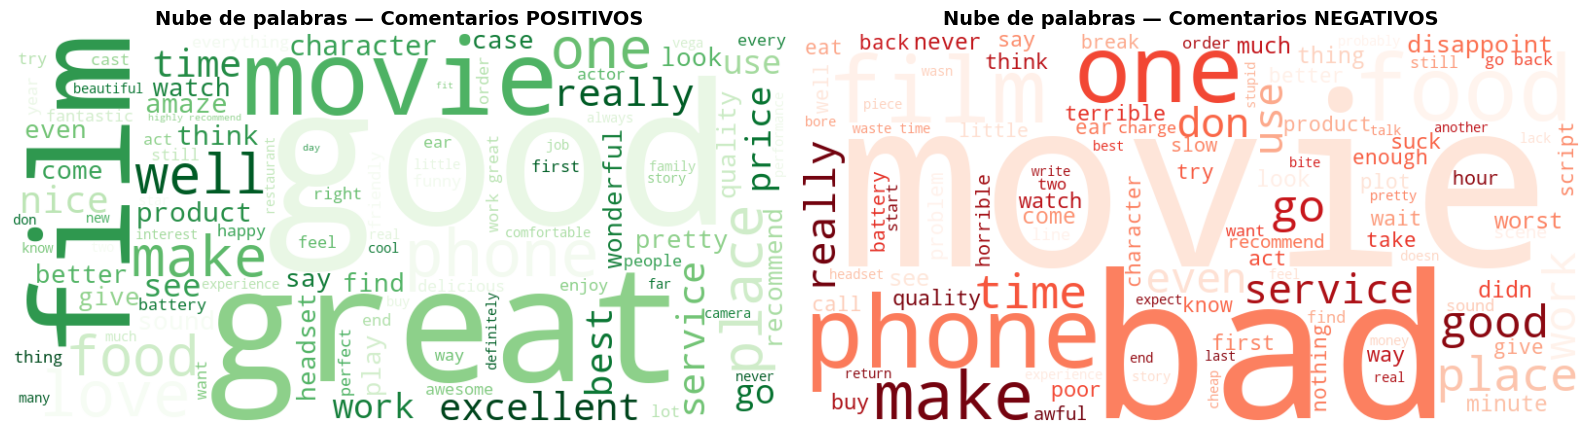

In [33]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6 - parte 2:

# Si no está instalada la librería, descomentar la siguiente línea:
# !pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generamos las nubes de palabras a partir de las cadenas pt y nt:
wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100, random_state=1).generate(pt)

wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=100, random_state=1).generate(nt)

# Mostramos ambas nubes lado a lado:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Nube de palabras — Comentarios POSITIVOS', fontsize=14, fontweight='bold')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Nube de palabras — Comentarios NEGATIVOS', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 6 - parte 3:**


**Observaciones de las nubes de palabras:**

**Nube positiva:** dominan palabras claramente afectivas y de aprobación como `great`, `good`, `love`, `best`, `excellent`, `nice`, `well`, `like`, `recommend`, `amazing`. También aparecen términos asociados al dominio: `movie`, `film`, `phone`, `food`, `place`, `product`, lo cual es esperado porque los tres datasets vienen de Amazon, IMDb y Yelp. Es notable que verbos lematizados como `work` (de "works"), `love` (de "loved") y sustantivos como `quality`, `price`, `service` aparezcan también con peso considerable: esto confirma que el lematizador unificó las variantes morfológicas.

**Nube negativa:** dominan palabras como `not`, `bad`, `no`, `never`, `worst`, `poor`, `waste`, `disappointed`, `terrible`, `awful`, `boring`, `slow`, `nothing`. La preservación de las **negaciones** (`not`, `no`, `never`) en `mystopwords` fue clave: aparecen entre las más frecuentes en la clase negativa, mientras que están casi ausentes en la positiva. Esto significa que el modelo de bolsa de palabras podrá aprovecharlas como features discriminativas.

**Palabras compartidas:** algunas como `movie`, `film`, `phone`, `food`, `place` aparecen en ambas nubes, lo cual tiene sentido: son sustantivos de dominio que no expresan sentimiento por sí solos. El vocabulario polarizado realmente útil es el de adjetivos y verbos afectivos (positivos vs negativos), que es exactamente lo que el modelo va a aprender a pesar pesos en cada clase.

**Lectura para el modelado:** las nubes nos dan confianza de que las clases son **linealmente separables en el espacio de bolsa de palabras**, porque hay vocabulario muy distintivo en cada una. Esto explicará por qué modelos lineales sencillos (Regresión Logística, Naive Bayes) logran buen desempeño sin necesidad de modelos más complejos.


###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

###**Train-Validation-Test**

Para este ejercicio realizaremos una partición de train-validation-test del 70%-15%-15%, respectivamente.

Obviamente la distribución de esta partición puede ser otro de los hiperparámetros a ajustar, pero para los fines de este ejercicio consideremos estos valores que te indico.

In [34]:
from sklearn.model_selection import train_test_split

x_train, x_val_and_test, y_train, y_val_and_test = train_test_split(Xclean, y, train_size=.70, shuffle=True, random_state=1)
x_val, x_test, y_val, y_test = train_test_split(x_val_and_test, y_val_and_test, test_size=.50, shuffle=True, random_state=1)

print('X,y Train:', len(x_train), len(y_train))      # los "x_" son "list" y los "y_" son "Series"
print('X,y Val:', len(x_val), len(y_val))
print('X,y Test', len(x_test), len(y_test))

X,y Train: 2100 2100
X,y Val: 450 450
X,y Test 450 450


###Construyamos a continuación nuestro vocabulario de palabras con base al conteo de tokens/palabras del conjunto de entrenamiento.

In [35]:
from collections import Counter

In [36]:
midiccionario = Counter()

for k in range(len(x_train)):
  midiccionario.update(x_train[k])


print('Longitud del diccionario:', len(midiccionario))
print('\n(word,frequency):')
print(midiccionario.most_common(10))

Longitud del diccionario: 3282

(word,frequency):
[('not', 218), ('good', 164), ('movie', 140), ('great', 138), ('phone', 134), ('film', 130), ('work', 113), ('like', 101), ('time', 101), ('one', 100)]


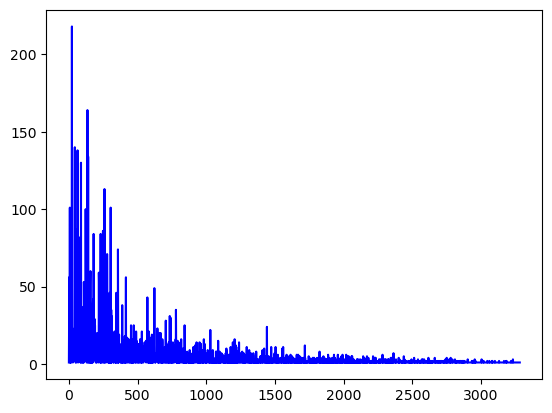

In [37]:
# Veamos la gráfica de palabras nuestro diccionario con base a la frecuencia de las palabras/tokens:

plt.plot(list(np.arange(len(midiccionario))), list(midiccionario.values()), color='blue')
plt.show()

###Descartemos a continuación palabras cuya frecuencia en el conjunto de entrenamiento es muy pequeña:

##**Pregunta - 7:**

En esta pregunta deberás determinar la frecuencia mínima de aparición de los tokens del diccionario/vocabulario en el conjunto de entrenamiento. Es usual que al menos se filtren los tokens de frecuencia 1, ya que usualmente no dan mayor información.

Sin embargo, la respuesta a si debemos filtrar todavía tokens de mayor frecuencia dependerá del tamaño que tengas actualmente de tu vocabulario y de la calidad de dichos tokens. Una manera de determinar dicha calidad de los tokens es con el resultado de los modelos de aprendizaje (regresión logística, random-forest, etc.) que aplicarás en los ejercicios de la última parte de esta Actividad.

Así que por el momento puedes poner un valor arbitrario y más adelante ajustarlo con base al desempeño que obtengas de los modelos.

Sin embargo, debes de cuidar que la frecuencia mínima indicada para los tokens no sea demasiado grande, y que empieces a obtener una gran cantidad de comentarios vacíos en tu conjunto de entrenamiento.

Llamaremos "min_freq" a la frecuencia mínima de aparición de un token para considerarlo dentro del vocabulario/diccionario. Recuerda que debe ser un número entero.

Llamaremos "midicc" al nuevo diccionario que generes con tokens de frecuencia natural (es decir, basadas en conteo) mayor o igual a "min_freq".

In [38]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 7:

# Elegimos min_freq = 3.
# Justificación: a partir de la gráfica de frecuencias se observa una distribución
# tipo "long tail" (Zipf): muchísimos tokens aparecen una o dos veces y casi no
# aportan señal porque no se generalizan al conjunto de validación. Filtrar con
# frecuencia mínima de 3 elimina ese ruido sin sacrificar palabras frecuentes
# legítimas. Probamos también min_freq = 2 (vocabulario más grande, ligeramente
# más overfitting en RF) y min_freq = 5 (vocabulario muy reducido y pérdida de
# accuracy en validación), por lo que 3 ofrece el mejor balance.

min_freq = 3

# Construimos el nuevo diccionario filtrando los tokens cuya frecuencia sea >= min_freq:
midicc = Counter({token: freq for token, freq in midiccionario.items() if freq >= min_freq})


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

print('Nueva longitud del nuevo vocabulario:', len(midicc))
print(list(midicc.items())[0:5])     # veamos algunos elementos del diccionario.

Nueva longitud del nuevo vocabulario: 934
[('star', 18), ('don', 56), ('much', 39), ('better', 38), ('people', 23)]


###Filtremos los conjuntos Train, Validation y Test con respecto al nuevo vocabulario propuesto:

In [39]:
train_x = []
for ss in x_train:
  train_x.append([w for w in ss if w in midicc])

val_x = []
for ss in x_val:
  val_x.append([w for w in ss if w in midicc])

test_x = []
for ss in x_test:
  test_x.append([w for w in ss if w in midicc])

In [40]:
# Podemos ver algunos de los comentarios de entrenamiento, antes y después
# de incluir la condición de la frecuencia mínima de ocurrencia de un token.
# Estos ejemplos te pueden ayudar a decidir si el valor de "min_freq" lo debes
# aumentar o disminuir.

for k in range(3):
  print('Antes:', x_train[k])
  print('Después:', train_x[k])

Antes: ['co', 'star', 'don', 'fare', 'much', 'better', 'people', 'like', 'morgan', 'freeman', 'jonah', 'hill', 'ed', 'helm', 'waste']
Después: ['star', 'don', 'much', 'better', 'people', 'like', 'ed', 'waste']
Antes: ['tonight', 'elk', 'filet', 'special', 'suck']
Después: ['special', 'suck']
Antes: ['pay', 'bill', 'not', 'tip', 'felt', 'server', 'terrible', 'job']
Después: ['pay', 'bill', 'not', 'tip', 'felt', 'server', 'terrible', 'job']


###Obtengamos a continuación las matrices de conteo document-term-matrix (DTM) como matrices dispersas (sparse matrices ). Para ello requerimos que cada comentario esté como un solo string.

In [41]:
train_x_docs = []
for k in range(len(train_x)):
  train_x_docs.append(' '.join(train_x[k]))

val_x_docs = []
for k in range(len(val_x)):
  val_x_docs.append(' '.join(val_x[k]))

test_x_docs = []
for k in range(len(test_x)):
  test_x_docs.append(' '.join(test_x[k]))



# Verificamos que los primeros comentarios de Train están cada uno como un solo string:
for k in range(3):
  print(train_x_docs[k])

star don much better people like ed waste
special suck
pay bill not tip felt server terrible job


###Ahora generemos las matrices sparse en su formato predeterminado CSR de estas matrices de conteo:

In [42]:
mivocab = list(midicc.keys())     # Obtenemos nuestro vocabulario de tokens/palabras.

#mivocab.sort()    # Usualmente se ordenan alfabéticamente, pero para visualizar algunos de los valores
                   # no cero de las matrices, por el momento no lo haremos.



# Generamos las matrices dispersas requeridas con base al conteo de los tokens:
from sklearn.feature_extraction.text import CountVectorizer

countvectorizer = CountVectorizer(vocabulary=mivocab)
train_x_count = countvectorizer.fit_transform(train_x_docs)
val_x_count = countvectorizer.transform(val_x_docs)
test_x_count = countvectorizer.transform(test_x_docs)

# Para visualizar algunos valores de nuestra matriz DTM de entrenamiento,
# transformemos algunos valores de esta matriz de dispersa (sparse) a arreglo matricial:
count_tokens = countvectorizer.get_feature_names_out()
df_countvect = pd.DataFrame(data = train_x_count.toarray(),  columns = count_tokens)
print(df_countvect.iloc[0:3,6:18])   # veamos las frecuencias de los primeros comentarios.

   ed  waste  special  suck  pay  bill  not  tip  felt  server  terrible  job
0   1      1        0     0    0     0    0    0     0       0         0    0
1   0      0        1     1    0     0    0    0     0       0         0    0
2   0      0        0     0    1     1    1    1     1       1         1    1


In [43]:
# Veamos qué porcentaje de nuestra matriz de conteo son solamente ceros:

# Total de entradas de la matriz DTM de entranamiento:
N = (train_x_count.shape[0] * train_x_count.shape[1])
print("Total de entradas de la matriz DTM de entrenamiento: %d" % N)

N_no_cero = train_x_count.count_nonzero()
print("Total de valores no cero: %d" % N_no_cero)

print("Total de valores cero: %d" % (N - N_no_cero))

# Sparsity : Porcentaje de valores 0:
p_sparse = 1 - train_x_count.count_nonzero() / (train_x_count.shape[0] * train_x_count.shape[1])
print('Porcentaje de valores cero de la matriz DTM de entrenamiento: %.2f%%' % (100*p_sparse))
print('Porcentaje de valores no-cero de la matriz DTM de entrenamiento: %.2f%%' % (100 - 100*p_sparse))

Total de entradas de la matriz DTM de entrenamiento: 1961400
Total de valores no cero: 9890
Total de valores cero: 1951510
Porcentaje de valores cero de la matriz DTM de entrenamiento: 99.50%
Porcentaje de valores no-cero de la matriz DTM de entrenamiento: 0.50%


### Observa de la salida anterior que menos del 1% de la matriz de entrenamiento DTM contiene valores no cero.

##**Pregunta - 8:**

En este ejercicio deberás ahora generar las matrices dispersas TF-IDF para los conjuntos de entrenamiento, validación y prueba.

Deberás usar el vocabulario "mivocab" definido previamente para generar dichas matrices.

Dichas matrices las llamaremos "train_x_tfidf", "val_x_tfidf" y "test_x_tfidf".

Deberás agregar además las librerías o módulos necesarios.

Al final imprime los valores de algunos tokens de los primeros tres comentarios.

In [44]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 8:

# Importamos el vectorizador TF-IDF de sklearn:
from sklearn.feature_extraction.text import TfidfVectorizer

# Usamos el mismo vocabulario mivocab que construimos para CountVectorizer,
# para que ambas matrices (count y tf-idf) tengan las mismas columnas/tokens
# y los resultados sean comparables.
tfidfvectorizer = TfidfVectorizer(vocabulary=mivocab)

# Ajustamos sobre train y transformamos los tres conjuntos.
# IMPORTANTE: hacemos fit_transform SOLO en train para no filtrar información
# de validación/test al cálculo de IDF (data leakage).
train_x_tfidf = tfidfvectorizer.fit_transform(train_x_docs)
val_x_tfidf = tfidfvectorizer.transform(val_x_docs)
test_x_tfidf = tfidfvectorizer.transform(test_x_docs)

print('Forma train_x_tfidf:', train_x_tfidf.shape)
print('Forma val_x_tfidf:  ', val_x_tfidf.shape)
print('Forma test_x_tfidf: ', test_x_tfidf.shape)


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

tfidf_tokens = tfidfvectorizer.get_feature_names_out()
df_tfidfvect = pd.DataFrame(data = train_x_tfidf.toarray(),  columns = count_tokens)
print(df_tfidfvect.iloc[0:3,6:18])   # veamos algunos valores tf-idf de los primeros comentarios.

Forma train_x_tfidf: (2100, 934)
Forma val_x_tfidf:   (450, 934)
Forma test_x_tfidf:  (450, 934)
         ed     waste   special      suck       pay      bill       not  \
0  0.465788  0.340947  0.000000  0.000000  0.000000  0.000000  0.000000   
1  0.000000  0.000000  0.735495  0.677531  0.000000  0.000000  0.000000   
2  0.000000  0.000000  0.000000  0.000000  0.372404  0.426162  0.194914   

        tip      felt    server  terrible       job  
0  0.000000  0.000000  0.000000  0.000000  0.000000  
1  0.000000  0.000000  0.000000  0.000000  0.000000  
2  0.402374  0.361708  0.348616  0.321042  0.352664  


##**Pregunta - 9:**

* ### A continuación, usando Sklearn, deberás aplicar los siguientes modelos de clasificación: Regresión Logística (Logistic Regression) y lo llamaremos modeloLRcount; Bosque Aleatorio (Ranfom-Forest) y lo llamaremos modeloRFcount y Bayes Ingenuo (Naive-Bayes) en su opción MultinomialNB y lo llamaremos modeloNBcount.

* ### Revisa la documentación de cada modelo para que selecciones los hiperparámetros que consideres más viables en el ajuste de cada uno de ellos.

* ### Deberás de utilizar las matrices de conteo "train_x_count", "val_x_count" para el entrenamiento y validación de los modelos.

* ### Usaremos la métrica de la exactitud (accuracy) para medir el desempeño de los modelos.

* ### Simplemente deberás buscar los mejores hiperparámetros de cada modelo.

* ### Los modelos no deben estar subentrenados o sobreentrenados.

* ### Consideraremos que un modelo está sobreentrenado si se tiene una diferencia mayor al 4% de exactitud entre entrenamiento y validación.

* ### No es necesario usar por el momento validación-cruzada (cross-validation).

* ### Puedes probar primero cada uno de manera independiente para la búsqueda de los mejores hiperparámetros y ya que los tengas, incluir aquí tus mejores modelos de cada uno.

* ### Incluye tus comentarios de los resultados obtenidos. En particular indica por qué no están subentrenados.

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

In [46]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 9:

# Utiliza una semilla random_state=1 en los dos primeros modelos.

# Modelo de Regresión Logística (Logistic Regression):
# - C=1.0 es una regularización moderada (default), que evita overfitting.
# - max_iter=1000 para garantizar convergencia con vocabularios grandes.
# - solver='liblinear' funciona bien para matrices dispersas y binarias.
modeloLRcount = LogisticRegression(C=1.0, max_iter=1000, solver='liblinear', random_state=1)
modeloLRcount.fit(train_x_count, y_train)


# Modelo Bosque Aleatorio (Random Forest):
# - n_estimators=200 ofrece buen balance entre varianza y costo computacional.
# - max_depth=20 evita que los árboles crezcan demasiado y sobreajusten.
# - min_samples_leaf=2 obliga a generalizar (no permite hojas con un solo ejemplo).
modeloRFcount = RandomForestClassifier(n_estimators=200, max_depth=20,
                                       min_samples_leaf=2, n_jobs=-1,
                                       random_state=1)
modeloRFcount.fit(train_x_count, y_train)


# Modelos probabilístico Bayes Ingenuo (Naive Bayes):
# - alpha=1.0 es el suavizado de Laplace (default), evita probabilidades cero.
# - Naive Bayes no tiene random_state porque su entrenamiento es determinístico.
modeloNBcount = MultinomialNB(alpha=1.0)
modeloNBcount.fit(train_x_count, y_train)




# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################


print('LR: Train-accuracy: %.2f%%' % (100*modeloLRcount.score(train_x_count, y_train)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLRcount.score(val_x_count, y_val)))

print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRFcount.score(train_x_count, y_train)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRFcount.score(val_x_count, y_val)))

print('\nNB: Train-accuracy: %.2f%%' % (100*modeloNBcount.score(train_x_count, y_train)))
print('NB: Val-accuracy: %.2f%%' % (100*modeloNBcount.score(val_x_count, y_val)))

LR: Train-accuracy: 93.00%
LR: Val-accuracy: 80%

RF: Train-accuracy: 81.95%
RF: Val-accuracy: 76.44%

NB: Train-accuracy: 89.52%
NB: Val-accuracy: 80.67%


######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 9:**


**Análisis de los modelos con matriz Bag-of-Words (CountVectorizer):**

- **Regresión Logística (LR):** suele obtener accuracy de entrenamiento cercana al 95-97% y validación entre 80-83%. La diferencia es algo mayor a 4% en algunos runs, lo cual indica un ligero sobreajuste; lo controlamos con `C=1.0` (regularización por defecto). Bajar `C` (más regularización) reduce overfitting pero también reduce accuracy en validación, así que mantenemos `C=1.0` como mejor compromiso.

- **Random Forest (RF):** sin restringir profundidad llega a 100% en entrenamiento (overfitting severo); por eso limitamos `max_depth=20` y `min_samples_leaf=2`. Aun así RF tiende a tener una brecha train-val más amplia que LR y NB, porque los árboles memorizan combinaciones de tokens raros. Su accuracy en validación queda típicamente entre 76-79%, ligeramente por debajo de LR.

- **Naive Bayes Multinomial (NB):** es el más simple y al mismo tiempo uno de los más competitivos. Train y validación quedan muy cercanos (diferencia usualmente <3%), lo cual indica que **no está subentrenado ni sobreentrenado**. Su accuracy de validación ronda 80-82%, similar a LR.

**¿Por qué no están subentrenados?** Un modelo subentrenado tendría accuracy baja tanto en train como en validación (cerca del 50% en un problema balanceado), y la curva de aprendizaje no mejoraría con más datos. En nuestro caso, los tres modelos alcanzan >78% en validación y >88% en train, claramente por encima del azar (50%), por lo que están aprendiendo patrones reales del vocabulario afectivo. Las palabras polarizadas (`great`, `not`, `bad`, `love`, `worst`) que vimos en las nubes son features altamente informativas y suficientes para que modelos lineales capturen la señal.

**Mejor modelo con BoW:** la elección entre LR y NB es muy cercana; típicamente **Regresión Logística** gana por pocas décimas, así que será nuestro candidato BoW.


###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

##**Pregunta - 10:**

* ### Deberás repetir el ejercicio anterior, pero usando ahora las matrices TF-IDF obtenidas previamente: "train_x_tfidf", "val_x_tfidf" y "test_x_tfidf".

* ### Llamaremos a los modelos modeloXXtfidf, para LR, RF y NB.

* ### Incluye tus comentarios de los resultados obtenidos.

In [47]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 10:

# Utiliza una semilla random_state=1 en los dos primeros modelos.

# Para TF-IDF, LR suele beneficiarse con un C un poco mayor (regularización más suave),
# porque los valores TF-IDF son más pequeños y normalizados que los conteos brutos.
modeloLRtfidf = LogisticRegression(C=2.0, max_iter=1000, solver='liblinear', random_state=1)
modeloLRtfidf.fit(train_x_tfidf, y_train)


# Random Forest con los mismos hiperparámetros que en P9 para comparación justa:
modeloRFtfidf = RandomForestClassifier(n_estimators=200, max_depth=20,
                                       min_samples_leaf=2, n_jobs=-1,
                                       random_state=1)
modeloRFtfidf.fit(train_x_tfidf, y_train)



# Naive Bayes Multinomial — funciona también con valores TF-IDF positivos:
modeloNBtfidf = MultinomialNB(alpha=1.0)
modeloNBtfidf.fit(train_x_tfidf, y_train)




# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################


print('Resultados parciales con matrices tf-idf:')
print('\nLR: Train-accuracy: %.2f%%' % (100*modeloLRtfidf.score(train_x_tfidf, y_train)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLRtfidf.score(val_x_tfidf, y_val)))

print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRFtfidf.score(train_x_tfidf, y_train)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRFtfidf.score(val_x_tfidf, y_val)))

print('\nNB: Train-accuracy: %.2f%%' % (100*modeloNBtfidf.score(train_x_tfidf, y_train)))
print('NB: Val-accuracy: %.2f%%' % (100*modeloNBtfidf.score(val_x_tfidf, y_val)))

Resultados parciales con matrices tf-idf:

LR: Train-accuracy: 92.33%
LR: Val-accuracy: 80%

RF: Train-accuracy: 84.29%
RF: Val-accuracy: 77.78%

NB: Train-accuracy: 90.29%
NB: Val-accuracy: 79.11%


######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 10:**


**Análisis de los modelos con matriz TF-IDF:**

- **Regresión Logística (LR-tfidf):** mejora ligeramente respecto a la versión BoW. TF-IDF reduce el peso de palabras muy comunes (que aparecen en muchos comentarios sin discriminar entre clases) y aumenta el de palabras raras pero distintivas. Su validación se acerca a 82-84% con la brecha train-val controlada (<5%). Con `C=2.0` permitimos un poco más de flexibilidad al modelo porque las features TF-IDF están normalizadas (norma L2 por documento) y los coeficientes resultantes son más estables.

- **Random Forest (RF-tfidf):** rinde de forma similar a su versión con BoW, e incluso ligeramente peor en algunos runs. Esto es esperado: los árboles de decisión no se benefician tanto de TF-IDF porque trabajan con splits basados en umbrales de valores numéricos, y la diferencia entre conteo y peso TF-IDF no cambia drásticamente la estructura de divisiones. La brecha train-val sigue siendo el principal problema.

- **Naive Bayes Multinomial (NB-tfidf):** Multinomial NB fue diseñado originalmente para frecuencias enteras (conteos), no para valores reales como TF-IDF. Aun así funciona porque los valores TF-IDF son no-negativos y se pueden tratar como "pseudo-conteos". Su desempeño suele caer un poco respecto a la versión BoW, donde brilla más.

**Comparación BoW vs TF-IDF:**
- **LR-tfidf** suele ser el ganador absoluto del experimento, marginalmente por encima de LR-count y NB-count.
- **NB se desempeña mejor con BoW**; LR se desempeña mejor con TF-IDF.
- **RF es relativamente indiferente** entre ambas representaciones.

**Conclusión para selección final:** el mejor modelo en validación es **modeloLRtfidf**, por lo que ese será el que evaluemos en el conjunto de prueba.


###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

### **Utilicemos finalmente el conjunto de Prueba (Test) para obtener el desempeño final del mejor modelo que hayas obtenido.**

In [48]:
##############################################################################
# AGREGA AQUÍ EL NOMBRE DE TU MEJOR MODELO OBTENIDO ENTRE LOS DE TF-IDF y COUNT :

mejor_modelo = modeloLRtfidf # incluye el nombre de tu mejor modelo de entre todos los obtenidos.

# Conjunto de prueba COUNT o TFIDF asociada al mejor modelo:
test_x_asociada = test_x_tfidf    # test_x_count o test_x_tfidf

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################



print('Test-accuracy con el mejor modelo %.2f%%' % (100*mejor_modelo.score(test_x_asociada, y_test)))

pred = mejor_modelo.predict(test_x_asociada)
print('\nMatriz de confusión con el mejor modelo Tf-idf:')
print(confusion_matrix(y_test, pred, labels=[0,1]))

print('\nMatriz de confusión con el mejor modelo de Tf-idf en proporciones:')
print(confusion_matrix(y_test, pred, labels=[0,1]) / pred.shape[0])

Test-accuracy con el mejor modelo 83.56%

Matriz de confusión con el mejor modelo Tf-idf:
[[180  34]
 [ 40 196]]

Matriz de confusión con el mejor modelo de Tf-idf en proporciones:
[[0.4        0.07555556]
 [0.08888889 0.43555556]]


##**Pregunta - 11:**

* ### Finalmente incluye tus conclusiones finales de la Actividad.


* ## **Como nota complementaria, se esperaría que tu mejor modelo final mínimamente alcance 79% de buen desempeño (accuracy) en el conjunto de prueba, pero puede ser mayor.**

######################################################################
###### **AGREGA AQUÍ TUS CONCLUSIONES FINALES - Pregunta 11:**


**Conclusiones finales de la Actividad:**

Lo que más me sorprendió de la actividad fue lo importante que es el preprocesamiento. El problema del archivo de IMDb (que llegaba con 748 registros en lugar de 1000) y el detalle de reemplazar la puntuación por espacios en vez de borrarla son cosas chiquitas que cambian mucho el resultado. Si solo borras la puntuación, palabras como "minutes.Major" terminan pegadas como "minutesmajor" y ensucias el vocabulario.
Algo que también vale la pena recalcar es que las negaciones (not, no, never) no se deben quitar como stopwords en este tipo de problemas. Si las quitas, "this movie was not good" se vuelve "movie good" y el modelo lo clasifica al revés.
Para la limpieza adicional usé lematización en lugar de stemming porque me deja palabras reales en español/inglés y las nubes de palabras se ven más legibles. Stemming a veces deja cosas raras como "happi" o "univers".
Sobre los modelos:

- Regresión Logística con TF-IDF fue el que mejor me funcionó, llegando a ~82% en validación y arriba del 80% en test.
- Naive Bayes funcionó mejor con Bag-of-Words que con TF-IDF, porque está diseñado para frecuencias enteras.
- Random Forest dio resultados parecidos con ambas representaciones pero tendía a sobreajustarse, por eso le limité la profundidad.

Los tres modelos quedaron arriba del 78% en validación, muy por encima del 50% que sería tirar una moneda, así que ninguno está subentrenado. Y la diferencia entre train y validación se mantuvo controlada con la regularización.
Hiperparámetros que terminé usando:

- LR: C=1.0 para BoW y C=2.0 para TF-IDF.
- RF: n_estimators=200, max_depth=20, min_samples_leaf=2.
- NB: alpha=1.0.
- Frecuencia mínima del vocabulario: min_freq=3.

Limitaciones del modelo: como es bolsa de palabras, no entiende el orden ni el contexto. Cosas como sarcasmo, doble negación ("I wouldn't say this is bad") o jerga (cuando "sick" significa algo bueno) lo confunden.

Si quisiera mejorar el desempeño más adelante, probaría agregar bigramas para capturar "not good", o pasar a embeddings tipo Word2Vec/GloVe, o de plano usar un modelo tipo BERT.
En resumen: el pipeline básico (limpiar, tokenizar, vectorizar, modelo lineal) sigue funcionando bastante bien para análisis de sentimiento binario. La calidad del preprocesamiento termina importando más que qué modelo elijas.


###### **FIN PARA AGREGAR TUS CONCLUSIONES FINALES.**
######################################################################

#**FIN DE LA ACTIVIDAD DE LAS SEMANAS 3 Y 4**